<a href="https://colab.research.google.com/github/srinehaaa/Srineha_160123771093_BDA_A2/blob/main/093_BDA_A2_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BDA ASSIGNMENT 2

Q1 : Build a classification model with spark with a dataset

In [2]:
!pip install pyspark
!wget -q https://raw.githubusercontent.com/plotly/datasets/master/iris-data.csv -O iris.csv

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("IrisAdvanced").getOrCreate()

# Load dataset (same but different approach)
data = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("iris.csv")

data.printSchema()

root
 |-- sepal length: double (nullable = true)
 |-- sepal width: double (nullable = true)
 |-- petal length: double (nullable = true)
 |-- petal width: double (nullable = true)
 |-- class: string (nullable = true)



In [4]:
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Convert label
label_index = StringIndexer(inputCol="class", outputCol="target")

# Combine features
vec = VectorAssembler(
    inputCols=data.columns[:-1],
    outputCol="input_features"
)

processed = label_index.fit(data).transform(data)
processed = vec.transform(processed)

processed.select("input_features", "target").show(5)

+-----------------+------+
|   input_features|target|
+-----------------+------+
|[5.1,3.5,1.4,0.2]|   0.0|
|[4.9,3.0,1.4,0.2]|   0.0|
|[4.7,3.2,1.3,0.2]|   0.0|
|[4.6,3.1,1.5,0.2]|   0.0|
|[5.0,3.6,1.4,0.2]|   0.0|
+-----------------+------+
only showing top 5 rows


In [5]:
train_data, test_data = processed.randomSplit([0.8, 0.2], seed=42)

from pyspark.ml.classification import LogisticRegression

model = LogisticRegression(
    featuresCol="input_features",
    labelCol="target",
    maxIter=15,
    regParam=0.05
)

lr_model = model.fit(train_data)

Predictions

In [6]:
results = lr_model.transform(test_data)

results.select("target", "prediction", "probability").show(10)

+------+----------+--------------------+
|target|prediction|         probability|
+------+----------+--------------------+
|   0.0|       0.0|[0.90190617407511...|
|   0.0|       0.0|[0.91689067115847...|
|   0.0|       0.0|[0.97064257652139...|
|   0.0|       0.0|[0.86658295349764...|
|   0.0|       0.0|[0.87042113672276...|
|   1.0|       1.0|[0.15475322577904...|
|   0.0|       0.0|[0.93309462570262...|
|   0.0|       0.0|[0.92809434453097...|
|   0.0|       0.0|[0.93932062469227...|
|   1.0|       1.0|[0.12383735274452...|
+------+----------+--------------------+
only showing top 10 rows


Evaluation

In [7]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

accuracy = accuracy_eval.evaluate(results)
f1 = f1_eval.evaluate(results)
precision = precision_eval.evaluate(results)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)

Accuracy: 1.0
F1 Score: 1.0
Precision: 1.0


CONFUSION MATRIX GRAPH


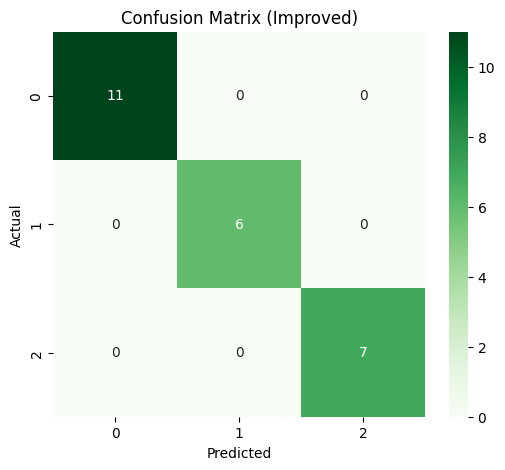

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

pdf = results.select("target", "prediction").toPandas()

cm = confusion_matrix(pdf["target"], pdf["prediction"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Improved)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

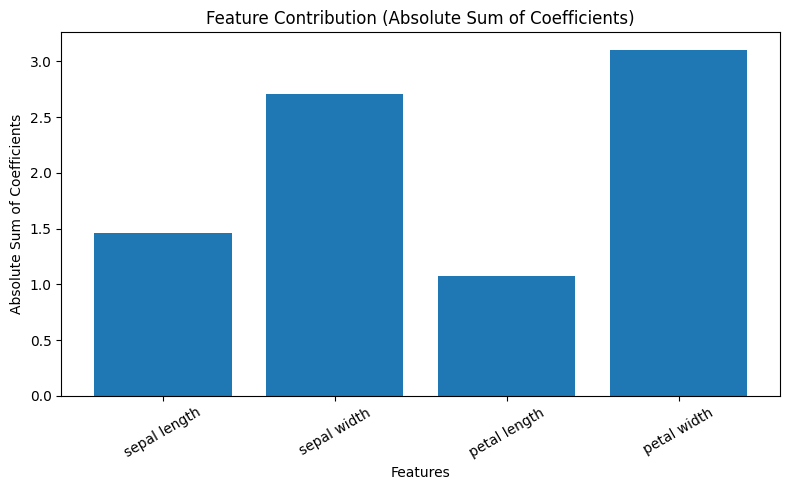

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

# Feature importance (coefficients)
# Multinomial models use coefficientMatrix
coeff_matrix = lr_model.coefficientMatrix.toArray()

# For a single plot, sum the absolute values of coefficients across classes for each feature
# Assuming features are columns and classes are rows in coeff_matrix
coeff_sum_abs = np.sum(np.abs(coeff_matrix), axis=0)

# Correct feature names (from data.columns[:-1])
features = ["sepal length", "sepal width", "petal length", "petal width"]

plt.figure(figsize=(8, 5))
plt.bar(features, coeff_sum_abs)
plt.title("Feature Contribution (Absolute Sum of Coefficients)")
plt.xlabel("Features")
plt.ylabel("Absolute Sum of Coefficients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()